In [ ]:
import os
# Run from the repository root so relative data/model/figure paths resolve
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
os.makedirs("figures", exist_ok=True)

# Model Inspection Notebook

This notebook allows reviewers to inspect the trained machine learning models used in the Workflow Energy Predictor application.

Both models are **Random Forest Regressors** (scikit-learn) trained on 3,890 WRENCH/SimGrid workflow simulations.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load models
with open("models/energy_model.pkl", "rb") as f:
    energy_model = pickle.load(f)
with open("models/makespan_model.pkl", "rb") as f:
    makespan_model = pickle.load(f)

print("Models loaded successfully.")

Models loaded successfully.


/Users/frankvillano/anaconda3/lib/python3.11/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.0 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/frankvillano/anaconda3/lib/python3.11/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.9.0 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 1. Model Architecture & Hyperparameters

In [2]:
print("=" * 60)
print("ENERGY MODEL")
print("=" * 60)
print(f"Type:              {type(energy_model).__name__}")
print(f"Number of trees:   {energy_model.n_estimators}")
print(f"Max depth:         {energy_model.max_depth} (None = unlimited)")
print(f"Min samples split: {energy_model.min_samples_split}")
print(f"Min samples leaf:  {energy_model.min_samples_leaf}")
print(f"Random state:      {energy_model.random_state}")
print(f"Number of features:{energy_model.n_features_in_}")
print(f"Features:          {list(energy_model.feature_names_in_)}")
print()
print("=" * 60)
print("MAKESPAN MODEL")
print("=" * 60)
print(f"Type:              {type(makespan_model).__name__}")
print(f"Number of trees:   {makespan_model.n_estimators}")
print(f"Max depth:         {makespan_model.max_depth} (None = unlimited)")
print(f"Min samples split: {makespan_model.min_samples_split}")
print(f"Min samples leaf:  {makespan_model.min_samples_leaf}")
print(f"Random state:      {makespan_model.random_state}")
print(f"Number of features:{makespan_model.n_features_in_}")
print(f"Features:          {list(makespan_model.feature_names_in_)}")

ENERGY MODEL
Type:              RandomForestRegressor
Number of trees:   300
Max depth:         None (None = unlimited)
Min samples split: 2
Min samples leaf:  1
Random state:      42
Number of features:16
Features:          ['ACTUAL_NUM_TASKS', 'NUM_EDGES', 'DAG_DEPTH', 'MAX_PARALLEL_WIDTH', 'CRITICAL_PATH_TASKS', 'NUM_TASK_CATEGORIES', 'TOTAL_INPUT_BYTES', 'PLATFORM_NUM_HOSTS', 'PLATFORM_CORES_PER_HOST', 'PLATFORM_HOST_SPEED_GF', 'PLATFORM_NET_BW_MBPS', 'PLATFORM_NET_LATENCY_MS', 'PLATFORM_DISK_BW_MBPS', 'PLATFORM_WATT_IDLE', 'PLATFORM_WATT_BUSY', 'PLATFORM_TOTAL_CORES']

MAKESPAN MODEL
Type:              RandomForestRegressor
Number of trees:   300
Max depth:         None (None = unlimited)
Min samples split: 2
Min samples leaf:  1
Random state:      42
Number of features:16
Features:          ['ACTUAL_NUM_TASKS', 'NUM_EDGES', 'DAG_DEPTH', 'MAX_PARALLEL_WIDTH', 'CRITICAL_PATH_TASKS', 'NUM_TASK_CATEGORIES', 'TOTAL_INPUT_BYTES', 'PLATFORM_NUM_HOSTS', 'PLATFORM_CORES_PER_HOST', 'PLATFO

## 2. Feature Importances

Shows which input features contribute most to each prediction.

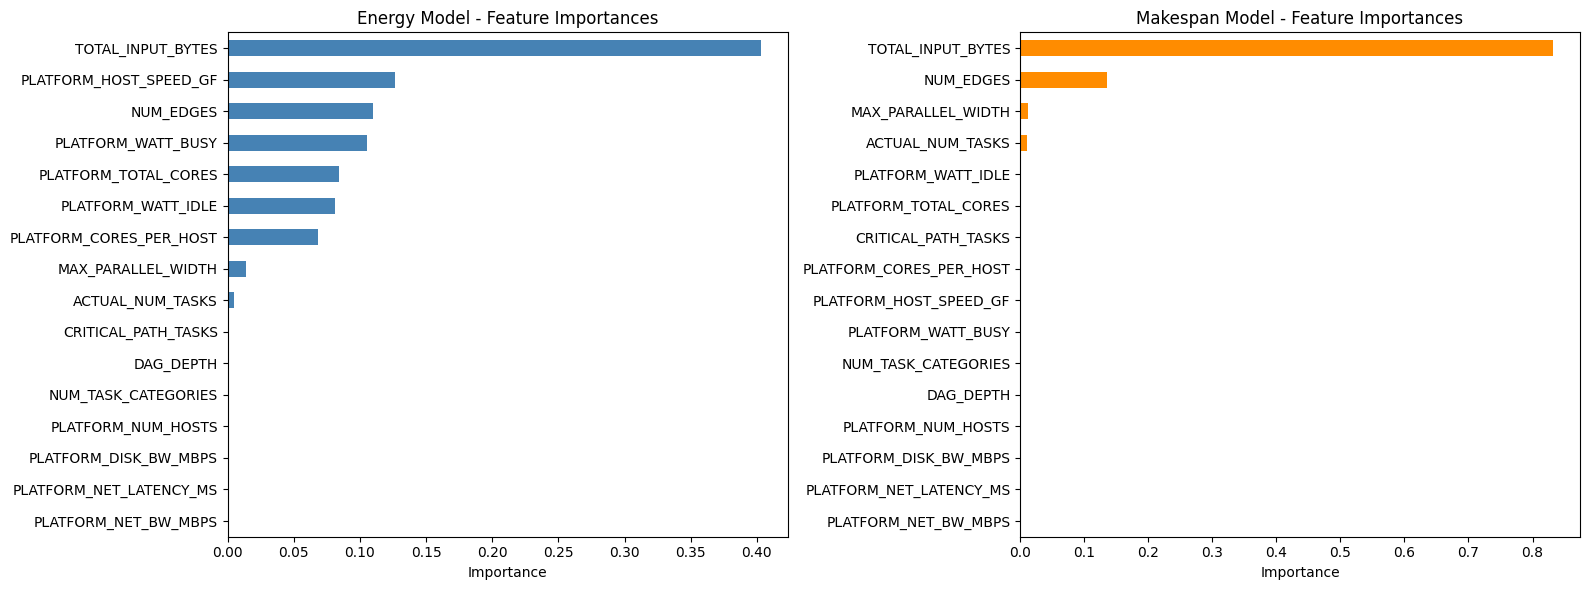

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Energy model
feat_imp_energy = pd.Series(
    energy_model.feature_importances_,
    index=energy_model.feature_names_in_
).sort_values(ascending=True)
feat_imp_energy.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Energy Model - Feature Importances")
axes[0].set_xlabel("Importance")

# Makespan model
feat_imp_makespan = pd.Series(
    makespan_model.feature_importances_,
    index=makespan_model.feature_names_in_
).sort_values(ascending=True)
feat_imp_makespan.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Makespan Model - Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 3. Individual Tree Inspection

Inspect properties of individual decision trees within the ensemble.

In [4]:
# Show depth and leaf count for first 10 trees
print('Energy Model - First 10 trees:')
header = '{:<6} {:<8} {:<8} {:<8}'.format('Tree', 'Depth', 'Leaves', 'Nodes')
print(header)
print('-' * 30)
for i, tree in enumerate(energy_model.estimators_[:10]):
    depth = tree.get_depth()
    leaves = tree.get_n_leaves()
    nodes = tree.tree_.node_count
    print('{:<6} {:<8} {:<8} {:<8}'.format(i, depth, leaves, nodes))

print()
print(f'Total trees in ensemble: {len(energy_model.estimators_)}')
print(f'Average tree depth: {np.mean([t.get_depth() for t in energy_model.estimators_]):.1f}')
print(f'Average leaves per tree: {np.mean([t.get_n_leaves() for t in energy_model.estimators_]):.0f}')


Energy Model - First 10 trees:
Tree   Depth    Leaves   Nodes   
------------------------------
0      22       1534     3067    
1      23       1546     3091    
2      22       1522     3043    
3      20       1534     3067    
4      20       1508     3015    
5      22       1542     3083    
6      23       1528     3055    
7      21       1526     3051    
8      21       1551     3101    
9      22       1535     3069    

Total trees in ensemble: 300
Average tree depth: 21.7
Average leaves per tree: 1528


## 4. Example Prediction

Demonstrates a prediction with a sample workflow input.

In [5]:
# Example: small Montage workflow on Dell PowerEdge R740
sample_input = {
    "ACTUAL_NUM_TASKS": 50,
    "NUM_EDGES": 120,
    "DAG_DEPTH": 8,
    "MAX_PARALLEL_WIDTH": 15,
    "CRITICAL_PATH_TASKS": 8,
    "NUM_TASK_CATEGORIES": 6,
    "TOTAL_INPUT_BYTES": 500_000_000,  # 500 MB
    "PLATFORM_NUM_HOSTS": 1,
    "PLATFORM_CORES_PER_HOST": 40,
    "PLATFORM_HOST_SPEED_GF": 43.2,
    "PLATFORM_NET_BW_MBPS": 25000,
    "PLATFORM_NET_LATENCY_MS": 0.001,
    "PLATFORM_DISK_BW_MBPS": 550,
    "PLATFORM_WATT_IDLE": 69.8,
    "PLATFORM_WATT_BUSY": 342,
    "PLATFORM_TOTAL_CORES": 40,
}

X = pd.DataFrame([sample_input])[list(energy_model.feature_names_in_)]

pred_energy = energy_model.predict(X)[0]
pred_makespan = makespan_model.predict(X)[0]

print(f"Sample input: 50-task workflow, 500 MB data, Dell R740 (40 cores)")
print(f"Predicted energy:  {pred_energy:.2f} Joules ({pred_energy/3600:.4f} Wh)")
print(f"Predicted makespan: {pred_makespan:.2f} seconds ({pred_makespan/60:.1f} min)")

Sample input: 50-task workflow, 500 MB data, Dell R740 (40 cores)
Predicted energy:  85.77 Joules (0.0238 Wh)
Predicted makespan: 1.55 seconds (0.0 min)


## 5. Training Data Overview

The models were trained on the dataset  included in this repository.

In [6]:
df = pd.read_csv('data/thesis_data.csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
print(f'Workflow types: {df["WORKFLOW_TYPE"].nunique()} types')
print(df['WORKFLOW_TYPE'].value_counts().to_string())
print()
print(f'Platforms: {df["PLATFORM_NAME"].nunique()} platforms')
print(df['PLATFORM_NAME'].value_counts().to_string())
print()
print('Target variable ranges:')
print(f'  Energy (J):   min={df["ENERGY_JOULES"].min():.1f}, max={df["ENERGY_JOULES"].max():.1f}')
print(f'  Makespan (s): min={df["SIMULATED_MAKESPAN_SEC"].min():.1f}, max={df["SIMULATED_MAKESPAN_SEC"].max():.1f}')


Dataset shape: 3890 rows x 20 columns

Workflow types: 10 types
WORKFLOW_TYPE
Epigenomics    500
Srasearch      500
Montage        450
Genome         450
Rnaseq         448
Cycles         430
Seismology     400
Blast          300
Soykb          292
Bwa            120

Platforms: 5 platforms
PLATFORM_NAME
lenovo_st45         820
lenovo_thinkedge    818
dell_r6715          768
dell_r6725          744
lenovo_sr850        740

Target variable ranges:
  Energy (J):   min=0.1, max=505187.0
  Makespan (s): min=0.0, max=6891.7


## 6. Model Evaluation on Test Set

Evaluates both models using a 70/30 train-test split (random_state=42) on the full dataset.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

FEATURE_COLS = list(energy_model.feature_names_in_)
X = df[FEATURE_COLS]
y_energy = df["ENERGY_JOULES"]
y_makespan = df["SIMULATED_MAKESPAN_SEC"]

X_train, X_test, y_train_e, y_test_e = train_test_split(X, y_energy, test_size=0.3, random_state=42)
_, _, y_train_m, y_test_m = train_test_split(X, y_makespan, test_size=0.3, random_state=42)

pred_energy = energy_model.predict(X_test)
pred_makespan = makespan_model.predict(X_test)

# Energy metrics
r2_e = r2_score(y_test_e, pred_energy)
rmse_e = mean_squared_error(y_test_e, pred_energy) ** 0.5
ape_e = (abs(y_test_e.values - pred_energy) / np.maximum(y_test_e.values, 1) * 100)
median_ape_e = np.median(ape_e)

# Makespan metrics
r2_m = r2_score(y_test_m, pred_makespan)
rmse_m = mean_squared_error(y_test_m, pred_makespan) ** 0.5
ape_m = (abs(y_test_m.values - pred_makespan) / np.maximum(y_test_m.values, 1) * 100)
median_ape_m = np.median(ape_m)

print("MODEL EVALUATION (70/30 split, random_state=42)")
print("=" * 50)
print(f"Test set size: {len(X_test)} samples")
print()
print("ENERGY MODEL:")
print(f"  R2:         {r2_e:.4f}")
print(f"  RMSE:       {rmse_e:.1f} J")
print(f"  Median APE: {median_ape_e:.1f}%")
print()
print("MAKESPAN MODEL:")
print(f"  R2:         {r2_m:.4f}")
print(f"  RMSE:       {rmse_m:.1f} s")
print(f"  Median APE: {median_ape_m:.1f}%")

MODEL EVALUATION (70/30 split, random_state=42)
Test set size: 1167 samples

ENERGY MODEL:
  R2:         0.9950
  RMSE:       4083.3 J
  Median APE: 1.7%

MAKESPAN MODEL:
  R2:         0.9164
  RMSE:       85.5 s
  Median APE: 0.5%


## 7. Resource Recommendation Evaluation

Evaluates the model's ability to recommend the optimal (lowest-energy) platform for each test workflow instance.

In [8]:
import warnings
warnings.filterwarnings('ignore')

FEATURE_COLS = list(energy_model.feature_names_in_)
wf_cols = FEATURE_COLS[:7]
plat_cols = FEATURE_COLS[7:]

# Platform configurations (one per platform)
platform_configs = df.drop_duplicates(subset='PLATFORM_NAME')[['PLATFORM_NAME'] + plat_cols].reset_index(drop=True)

# Mean energy per (WORKFLOW_TYPE, ACTUAL_NUM_TASKS, PLATFORM_NAME)
true_best_map = df.groupby(['WORKFLOW_TYPE', 'ACTUAL_NUM_TASKS', 'PLATFORM_NAME'])['ENERGY_JOULES'].mean().reset_index()
true_best_pivot = true_best_map.pivot_table(index=['WORKFLOW_TYPE', 'ACTUAL_NUM_TASKS'], columns='PLATFORM_NAME', values='ENERGY_JOULES')
# Only evaluate on configurations where ALL platforms were successfully simulated,
# so every strategy is compared on the same workflows (avoids treating missing data as zero energy).
complete_configs = set(true_best_pivot.dropna().index)
true_best_per_config = {k: true_best_pivot.loc[k].idxmin() for k in complete_configs}

# Test set (same split as Section 6), restricted to complete configurations
X_train, X_test, _, _ = train_test_split(df[FEATURE_COLS], df['ENERGY_JOULES'], test_size=0.3, random_state=42)
df_test = df.loc[X_test.index].copy()
df_test = df_test[df_test.apply(lambda r: (r['WORKFLOW_TYPE'], r['ACTUAL_NUM_TASKS']) in complete_configs, axis=1)]
df_test['TRUE_BEST'] = df_test.apply(lambda r: true_best_per_config[(r['WORKFLOW_TYPE'], r['ACTUAL_NUM_TASKS'])], axis=1)

# For each test row: predict energy on all 5 platforms, recommend lowest
model_recs = []
for idx, row in df_test.iterrows():
    wf_feats = row[wf_cols].values.astype(float)
    best_plat, best_pred = None, float('inf')
    for _, pc in platform_configs.iterrows():
        inp = pd.DataFrame([np.concatenate([wf_feats, pc[plat_cols].values.astype(float)])], columns=FEATURE_COLS)
        pred = energy_model.predict(inp)[0]
        if pred < best_pred:
            best_pred = pred
            best_plat = pc['PLATFORM_NAME']
    model_recs.append(best_plat)

df_test['MODEL_REC'] = model_recs

# Correctness
model_correct = (df_test['MODEL_REC'] == df_test['TRUE_BEST']).sum()
st45_correct = (df_test['TRUE_BEST'] == 'lenovo_st45').sum()
total = len(df_test)

# Energy totals (all lookups exist because we restricted to complete configurations)
energy_lookup = df.groupby(['WORKFLOW_TYPE', 'ACTUAL_NUM_TASKS', 'PLATFORM_NAME'])['ENERGY_JOULES'].mean().to_dict()
model_energy = st45_energy = worst_energy = random_energy = 0.0

for idx, row in df_test.iterrows():
    key = (row['WORKFLOW_TYPE'], row['ACTUAL_NUM_TASKS'])
    model_energy += energy_lookup[(*key, row['MODEL_REC'])]
    st45_energy += energy_lookup[(*key, 'lenovo_st45')]
    worst_energy += energy_lookup[(*key, 'lenovo_sr850')]
    random_energy += np.mean([energy_lookup[(*key, p)] for p in platform_configs['PLATFORM_NAME']])

print("RESOURCE RECOMMENDATION EVALUATION")
print("=" * 50)
print(f"Evaluated on: {total} test instances (30% held-out, complete platform configs)")
print()
print(f"{'Strategy':<30} {'Energy (MJ)':>12} {'vs Worst':>10} {'Correct':>10}")
print("-" * 65)
print(f"{'Proposed ML recommender':<30} {model_energy/1e6:>12.2f} {f'-{(1-model_energy/worst_energy)*100:.1f}%':>10} {f'{model_correct/total*100:.1f}%':>10}")
print(f"{'Always Lenovo ST45':<30} {st45_energy/1e6:>12.2f} {f'-{(1-st45_energy/worst_energy)*100:.1f}%':>10} {f'{st45_correct/total*100:.1f}%':>10}")
print(f"{'Random selection':<30} {random_energy/1e6:>12.2f} {f'-{(1-random_energy/worst_energy)*100:.1f}%':>10} {'20.0%':>10}")
print(f"{'Always Lenovo SR850 (worst)':<30} {worst_energy/1e6:>12.2f} {'0%':>10} {'0%':>10}")

RESOURCE RECOMMENDATION EVALUATION
Evaluated on: 1079 test instances (30% held-out, complete platform configs)

Strategy                        Energy (MJ)   vs Worst    Correct
-----------------------------------------------------------------
Proposed ML recommender                5.47     -93.4%      86.7%
Always Lenovo ST45                     5.58     -93.3%      59.9%
Random selection                      28.95     -65.1%      20.0%
Always Lenovo SR850 (worst)           82.92         0%         0%


## 8. Feature Correlation Matrix

Pearson correlation matrix of all 16 input features, showing orthogonality between workflow and platform feature groups.

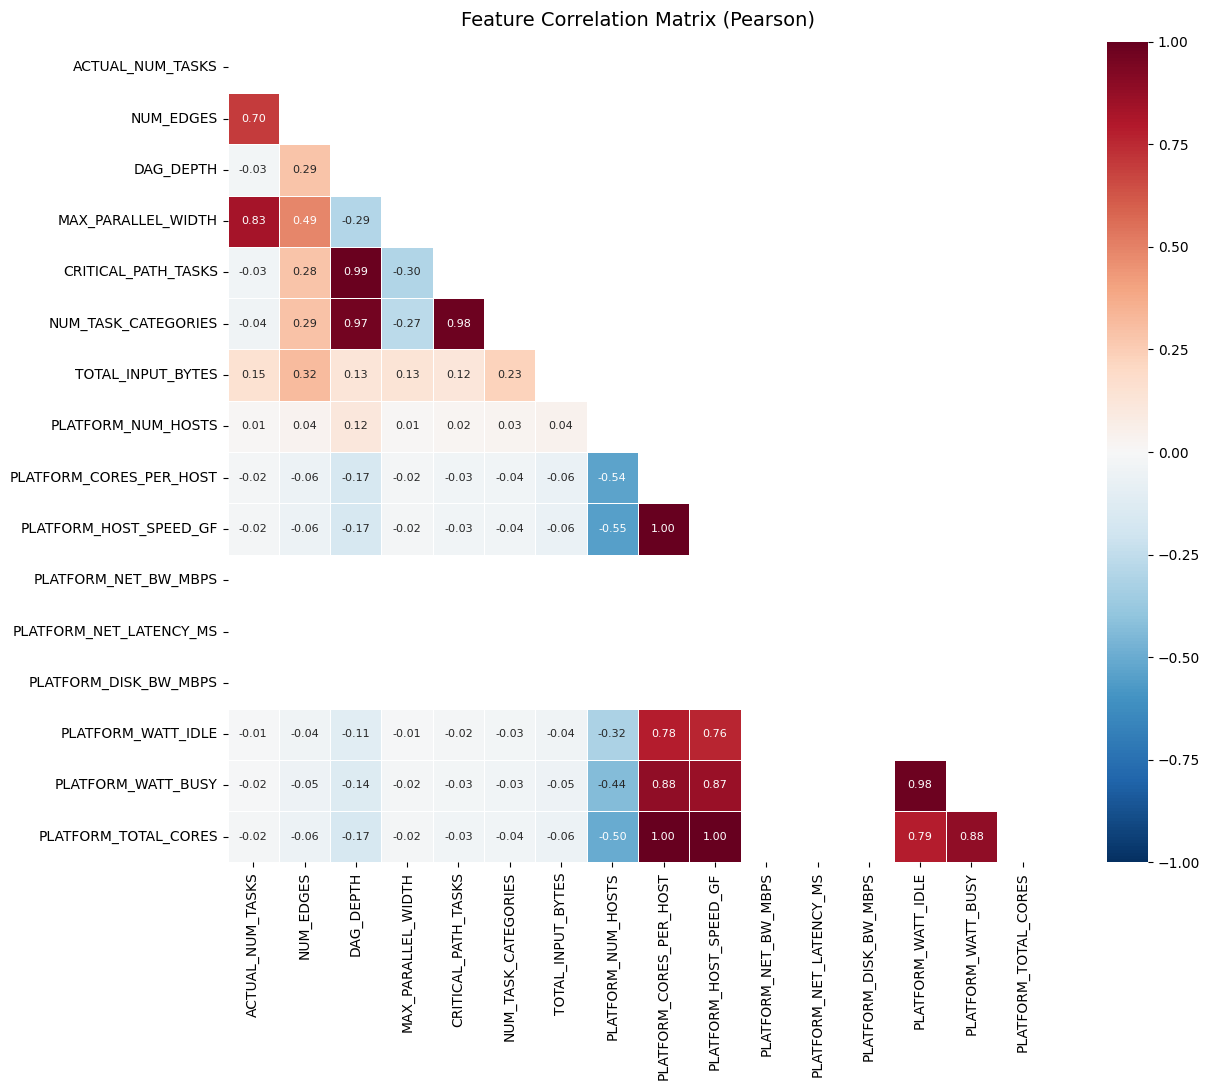


Key correlations:
  num_tasks vs num_edges: 0.701
  num_tasks vs total_input_bytes: 0.154
  total_cores vs host_speed_gf: 0.998
  watt_busy vs total_cores: 0.884
  workflow vs platform features: ~0 (orthogonal)


In [9]:
import seaborn as sns

corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Feature Correlation Matrix (Pearson)', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey correlations:")
print(f"  num_tasks vs num_edges: {corr.loc['ACTUAL_NUM_TASKS','NUM_EDGES']:.3f}")
print(f"  num_tasks vs total_input_bytes: {corr.loc['ACTUAL_NUM_TASKS','TOTAL_INPUT_BYTES']:.3f}")
print(f"  total_cores vs host_speed_gf: {corr.loc['PLATFORM_TOTAL_CORES','PLATFORM_HOST_SPEED_GF']:.3f}")
print(f"  watt_busy vs total_cores: {corr.loc['PLATFORM_WATT_BUSY','PLATFORM_TOTAL_CORES']:.3f}")
print(f"  workflow vs platform features: ~0 (orthogonal)")

## 9. Predicted vs Actual (Split Figures)

Separate full-width figures for energy and makespan prediction accuracy.

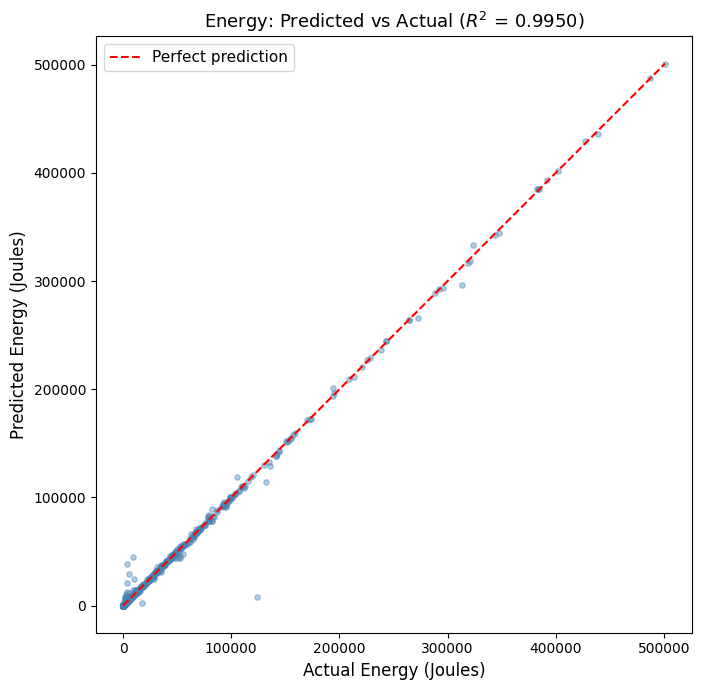

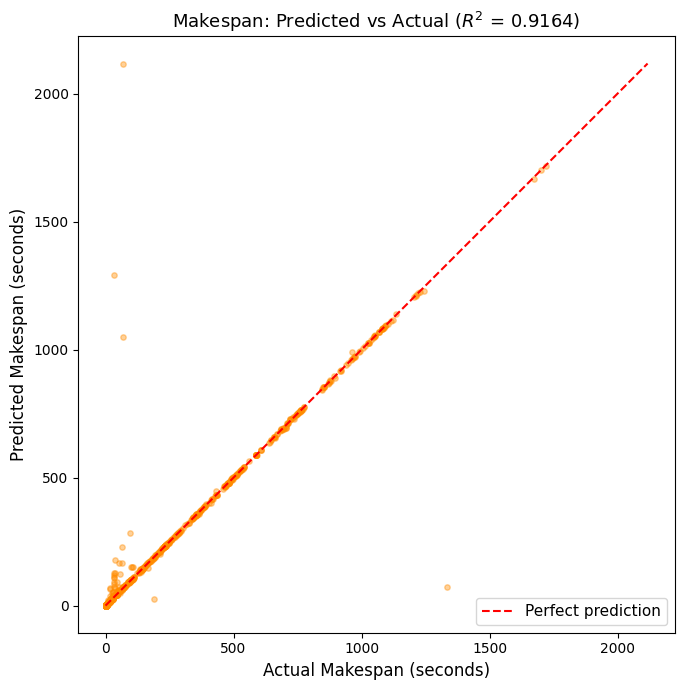

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[FEATURE_COLS]
y_energy = df["ENERGY_JOULES"]
y_makespan = df["SIMULATED_MAKESPAN_SEC"]
X_train, X_test, y_train_e, y_test_e = train_test_split(X, y_energy, test_size=0.3, random_state=42)
_, _, y_train_m, y_test_m = train_test_split(X, y_makespan, test_size=0.3, random_state=42)

pred_energy = energy_model.predict(X_test)
pred_makespan = makespan_model.predict(X_test)

# Energy figure
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test_e, pred_energy, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test_e.min(), pred_energy.min()), max(y_test_e.max(), pred_energy.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Energy (Joules)', fontsize=12)
ax.set_ylabel('Predicted Energy (Joules)', fontsize=12)
ax.set_title(f'Energy: Predicted vs Actual ($R^2$ = {r2_score(y_test_e, pred_energy):.4f})', fontsize=13)
ax.legend(fontsize=11)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig('figures/pred_vs_actual_energy.png', dpi=150, bbox_inches='tight')
plt.show()

# Makespan figure
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test_m, pred_makespan, alpha=0.4, s=15, color='darkorange')
lims = [min(y_test_m.min(), pred_makespan.min()), max(y_test_m.max(), pred_makespan.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Makespan (seconds)', fontsize=12)
ax.set_ylabel('Predicted Makespan (seconds)', fontsize=12)
ax.set_title(f'Makespan: Predicted vs Actual ($R^2$ = {r2_score(y_test_m, pred_makespan):.4f})', fontsize=13)
ax.legend(fontsize=11)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig('figures/pred_vs_actual_makespan.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. A Hybrid Model for Cross-Platform Generalization

Experiment 4 showed the direct Random Forest cannot extrapolate energy to unseen platforms. This section evaluates a hybrid model (a gray-box approach) that instead learns the *platform-independent* quantities (makespan and total compute work) from pre-execution metadata and plugs them into SimGrid's energy formula, supplying the platform power/speed/core values exactly from the platform table:

`E = num_hosts * watt_idle * makespan + (watt_busy - watt_idle) * work / (speed * cores_per_host)`

- **Table A** (main `thesis_data.csv`, 10 types): idle*makespan hybrid vs direct RF, leave-one-platform-out.
- **Table B** (augmented `hybrid/full_dataset.csv`, 5 types, stores per-task runtimes): the full hybrid (makespan + work term) vs direct RF.

See `hybrid/README.md` for details. Makespan and work are used only as training labels; all model inputs at prediction time are pre-execution metadata.

## 11. Robustness Analysis (Experiments 1, 3, 5)

Reproduces the robustness tables from the Results section using the same no-log Random Forest
pipeline as the deployed model (`n_estimators=300`, `max_depth=None`, `random_state=42`) on the
70/30 `random_state=42` split of `thesis_data.csv`.

- **Experiment 1 - Synthetic noise injection** (`tab:noise`): Gaussian multiplicative noise is
  applied to the *training* energy labels only; accuracy is measured against the *clean* held-out
  targets, testing whether the model still recovers true energy from noisy training labels.
- **Experiment 3 - Cross-workflow generalization** (`tab:cross_wf`): leave-one-workflow-type-out.
- **Experiment 5 - Task-count interpolation** (`tab:interpolation`): the middle task count of each
  workflow type is held out and predicted from the remaining (adjacent) counts.

Median APE values may differ slightly from the thesis tables due to the scikit-learn
version (most within a few tenths of a percentage point; individual interpolation rows
such as Montage may differ more because a single held-out split is sensitive to tree
tie-breaking); all $R^2$ values match.

In [14]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

FEATURE_COLS = list(energy_model.feature_names_in_)
X = df[FEATURE_COLS]
y_energy = df["ENERGY_JOULES"]
RF = lambda: RandomForestRegressor(n_estimators=300, max_depth=None,
                                   random_state=42, n_jobs=-1)
def median_ape(yt, yp): return float(np.median(np.abs(yt - yp) / np.maximum(yt, 1) * 100))
def mean_ape(yt, yp):   return float(np.mean(np.abs(yt - yp) / np.maximum(yt, 1) * 100))

# ---- Experiment 1: synthetic noise on training labels, evaluated vs clean test ----
print("EXPERIMENT 1 - Synthetic noise injection (tab:noise)")
print(f"{'Noise level':<14}{'Test R2':>10}{'Median APE':>13}")
print("-" * 37)
for nz in [0, 5, 10, 15, 20]:
    Xtr, Xte, ytr, yte = train_test_split(X, y_energy.values, test_size=0.3, random_state=42)
    ytr_noisy = ytr.copy()
    if nz > 0:
        ytr_noisy = ytr_noisy * np.random.RandomState(42).normal(1.0, nz / 100, size=len(ytr_noisy))
    p = RF().fit(Xtr, ytr_noisy).predict(Xte)
    tag = "0% (original)" if nz == 0 else f"{nz}%"
    print(f"{tag:<14}{r2_score(yte, p):>10.3f}{median_ape(yte, p):>12.1f}%")

# ---- Experiment 3: leave-one-workflow-type-out ----
print("\nEXPERIMENT 3 - Cross-workflow generalization (tab:cross_wf)")
print(f"{'Held-out type':<14}{'Test R2':>10}{'MAPE':>10}{'N':>7}")
print("-" * 41)
rows = []
for t in df["WORKFLOW_TYPE"].unique():
    tr = df["WORKFLOW_TYPE"] != t
    te = ~tr
    p = RF().fit(X[tr], y_energy[tr]).predict(X[te])
    rows.append((t, r2_score(y_energy[te], p), mean_ape(y_energy[te].values, p), int(te.sum())))
for t, r2, ape, n in sorted(rows, key=lambda r: -r[1]):
    print(f"{t:<14}{r2:>10.3f}{ape:>9.1f}%{n:>7}")

# ---- Experiment 5: task-count interpolation (hold out middle count per type) ----
print("\nEXPERIMENT 5 - Task-count interpolation (tab:interpolation)")
print(f"{'Workflow type':<14}{'Held-out':>9}{'Neighbors':>14}{'Median APE':>13}")
print("-" * 50)
irows = []
for t in df["WORKFLOW_TYPE"].unique():
    counts = sorted(df.loc[df["WORKFLOW_TYPE"] == t, "ACTUAL_NUM_TASKS"].unique())
    if len(counts) < 3:
        continue
    i = len(counts) // 2
    mid = counts[i]
    neigh = f"{counts[i-1]}...{counts[i+1]}"
    te = (df["WORKFLOW_TYPE"] == t) & (df["ACTUAL_NUM_TASKS"] == mid)
    p = RF().fit(X[~te], y_energy[~te]).predict(X[te])
    irows.append((t, mid, neigh, median_ape(y_energy[te].values, p)))
for t, mid, neigh, ape in sorted(irows, key=lambda r: r[3]):
    print(f"{t:<14}{mid:>9}{neigh:>14}{ape:>12.1f}%")
print(f"\nAverage interpolation APE: {np.mean([r[3] for r in irows]):.1f}%")


EXPERIMENT 1 - Synthetic noise injection (tab:noise)
Noise level      Test R2   Median APE
-------------------------------------
0% (original)      0.995         1.6%
5%                 0.994         2.9%
10%                0.991         4.7%
15%                0.986         6.7%
20%                0.980         8.2%

EXPERIMENT 3 - Cross-workflow generalization (tab:cross_wf)
Held-out type    Test R2      MAPE      N
-----------------------------------------
Soykb              0.964     10.2%    292
Blast              0.818     17.3%    300
Genome             0.788     70.9%    450
Srasearch          0.636     50.6%    500
Montage           -0.059     69.6%    450
Cycles            -0.320     49.1%    430
Bwa               -0.472     56.1%    120
Rnaseq            -9.198    337.2%    448
Seismology       -11.507    645.9%    400
Epigenomics      -22.487    525.6%    500

EXPERIMENT 5 - Task-count interpolation (tab:interpolation)
Workflow type  Held-out     Neighbors   Median APE
----

## 12. Model Selection (Answering SQ2)

Reproduces the model-comparison tables and the Random-Forest-vs-Gradient-Boosting selection
argument from the Results section, using a single consistent no-log pipeline on the 70/30
`random_state=42` split. The Random Forest row uses the deployed model (`models/energy_model.pkl`,
`models/makespan_model.pkl`); all other models are trained fresh with default settings, except
Gradient Boosting which uses the project's configuration (`n_estimators=300`, `max_depth=4`,
`learning_rate=0.05`, `subsample=0.8`).

In [12]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

FEATURE_COLS = list(energy_model.feature_names_in_)
X = df[FEATURE_COLS]
def med_ape(yt, yp): return float(np.median(np.abs(yt - yp) / np.maximum(yt, 1) * 100))
def GB(): return GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                           learning_rate=0.05, subsample=0.8, random_state=42)

def comparison(target, saved_model):
    y = df[target]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)
    fresh = [("Linear Regression", LinearRegression()),
             ("Ridge Regression", Ridge(alpha=1.0)),
             ("Decision Tree", DecisionTreeRegressor(random_state=42)),
             ("Gradient Boosting", GB())]
    out = {}
    for name, m in fresh:
        m.fit(Xtr, ytr); p = m.predict(Xte)
        out[name] = (r2_score(yte, p), mean_squared_error(yte, p) ** 0.5, med_ape(yte.values, p))
    p = saved_model.predict(Xte)
    out["Random Forest"] = (r2_score(yte, p), mean_squared_error(yte, p) ** 0.5, med_ape(yte.values, p))
    return out

for target, saved, unit in [("ENERGY_JOULES", energy_model, "J"),
                            ("SIMULATED_MAKESPAN_SEC", makespan_model, "s")]:
    print(f"MODEL COMPARISON - {target}")
    print(f"{'Model':<20}{'Test R2':>9}{'RMSE ('+unit+')':>12}{'Median APE':>13}")
    print("-" * 54)
    res = comparison(target, saved)
    dec = 1 if unit == "s" else 0
    for name in ["Linear Regression", "Ridge Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]:
        r2, rmse, ape = res[name]
        print(f"{name:<20}{r2:>9.3f}{rmse:>12,.{dec}f}{ape:>12.1f}%")
    print()

# ---- RF vs GB under stricter conditions (cross-workflow + noise) ----
y = df["ENERGY_JOULES"]
def lopo_meanR2(make):
    r2s = {}
    for t in df["WORKFLOW_TYPE"].unique():
        tr = df["WORKFLOW_TYPE"] != t
        p = make().fit(X[tr], y[tr]).predict(X[~tr])
        r2s[t] = r2_score(y[~tr], p)
    return r2s
rf_lopo = lopo_meanR2(lambda: RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1))
gb_lopo = lopo_meanR2(GB)
pos = [t for t in rf_lopo if rf_lopo[t] > 0]
print("CROSS-WORKFLOW (mean R2 over types where RF generalizes positively):")
print(f"  positive types: {sorted(pos)}")
print(f"  RF mean R2 = {np.mean([rf_lopo[t] for t in pos]):.2f}   GB mean R2 = {np.mean([gb_lopo[t] for t in pos]):.2f}")

def noise20_ape(make):
    Xtr, Xte, ytr, yte = train_test_split(X, y.values, test_size=0.3, random_state=42)
    ytr_n = ytr * np.random.RandomState(42).normal(1.0, 0.20, size=len(ytr))
    return med_ape(yte, make().fit(Xtr, ytr_n).predict(Xte))
print("\nNOISE ROBUSTNESS (Median APE at 20% target noise):")
print(f"  RF = {noise20_ape(lambda: RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)):.1f}%   GB = {noise20_ape(GB):.1f}%")


MODEL COMPARISON - ENERGY_JOULES
Model                 Test R2    RMSE (J)   Median APE
------------------------------------------------------
Linear Regression       0.496      41,075       580.8%
Ridge Regression        0.496      41,075       580.6%
Decision Tree           0.986       6,781         1.4%
Random Forest           0.995       4,083         1.7%
Gradient Boosting       0.990       5,729        20.4%

MODEL COMPARISON - SIMULATED_MAKESPAN_SEC
Model                 Test R2    RMSE (s)   Median APE
------------------------------------------------------
Linear Regression       0.935        75.2        87.8%
Ridge Regression        0.935        75.2        87.8%
Decision Tree          -0.375       346.7         0.5%
Random Forest           0.916        85.5         0.5%
Gradient Boosting       0.467       215.8         9.5%

CROSS-WORKFLOW (mean R2 over types where RF generalizes positively):
  positive types: ['Blast', 'Genome', 'Soykb', 'Srasearch']
  RF mean R2 = 0.80   GB

## 13. Additional Reported Statistics

Reproduces the remaining numeric claims in the Results section: the full energy feature-importance
ranking (`tab:feature_importance_full`), the feature correlations cited in Section 5.1, the
test-set mean / 90th-percentile APE (Prediction Accuracy), and the optimal-platform win
distribution (`fig:platform_wins`).

In [ ]:
import numpy as np, pandas as pd
FEATURE_COLS = list(energy_model.feature_names_in_)
WF = FEATURE_COLS[:7]; PLAT = FEATURE_COLS[7:]

# ---- Feature importance ranking (tab:feature_importance_full) ----
fi = pd.Series(energy_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("FEATURE IMPORTANCE (energy)")
for i, (name, val) in enumerate(fi.head(8).items(), 1):
    cat = "Workflow" if name in WF else "Platform"
    print(f"  {i}. {name:<26}{val:.3f}  {cat}")

# ---- Correlations cited in Section 5.1 ----
C = df[FEATURE_COLS].corr().abs()
print("\nCORRELATIONS (|Pearson r|)")
print(f"  CRITICAL_PATH_TASKS vs NUM_TASK_CATEGORIES = {C.loc['CRITICAL_PATH_TASKS','NUM_TASK_CATEGORIES']:.2f}")
print(f"  DAG_DEPTH vs CRITICAL_PATH_TASKS / NUM_TASK_CATEGORIES = "
      f"{C.loc['DAG_DEPTH','CRITICAL_PATH_TASKS']:.2f} / {C.loc['DAG_DEPTH','NUM_TASK_CATEGORIES']:.2f}")
print(f"  MAX_PARALLEL_WIDTH vs ACTUAL_NUM_TASKS = {C.loc['MAX_PARALLEL_WIDTH','ACTUAL_NUM_TASKS']:.2f}")
print(f"  TOTAL_INPUT_BYTES vs other workflow feats (max) = {C.loc['TOTAL_INPUT_BYTES', [c for c in WF if c!='TOTAL_INPUT_BYTES']].max():.3f}")
print(f"  PLATFORM_TOTAL_CORES vs PLATFORM_HOST_SPEED_GF = {C.loc['PLATFORM_TOTAL_CORES','PLATFORM_HOST_SPEED_GF']:.2f}")
wc = [C.loc[w,'PLATFORM_TOTAL_CORES'] for w in ['PLATFORM_WATT_BUSY','PLATFORM_WATT_IDLE']]
print(f"  WATT_BUSY/IDLE vs TOTAL_CORES = {min(wc):.2f}-{max(wc):.2f}")
cross = np.nanmax(C.loc[WF, PLAT].values)  # zero-variance platform cols give NaN; ignore them
print(f"  max |r| across workflow-vs-platform pairs = {cross:.3f}")

# ---- Test-set APE distribution (Prediction Accuracy) ----
X = df[FEATURE_COLS]; y = df["ENERGY_JOULES"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)
ape = np.abs(yte.values - energy_model.predict(Xte)) / np.maximum(yte.values, 1) * 100
print(f"\nENERGY APE on test set ({len(yte)} samples): mean={ape.mean():.1f}%  p90={np.percentile(ape,90):.1f}%")

# ---- Optimal-platform win distribution (fig:platform_wins) ----
pivot = (df.groupby(['WORKFLOW_TYPE','ACTUAL_NUM_TASKS','PLATFORM_NAME'])['ENERGY_JOULES']
           .mean().reset_index()
           .pivot_table(index=['WORKFLOW_TYPE','ACTUAL_NUM_TASKS'], columns='PLATFORM_NAME', values='ENERGY_JOULES'))
complete = pivot.dropna()
wins = complete.idxmin(axis=1).value_counts()
print(f"\nOPTIMAL PLATFORM over {len(complete)} complete configurations:")
for plat, n in wins.items():
    print(f"  {plat:<18}{n:>4}  ({n/len(complete)*100:.0f}%)")


FEATURE IMPORTANCE (energy)
  1. TOTAL_INPUT_BYTES         0.403  Workflow
  2. PLATFORM_HOST_SPEED_GF    0.127  Platform
  3. NUM_EDGES                 0.110  Workflow
  4. PLATFORM_WATT_BUSY        0.105  Platform
  5. PLATFORM_TOTAL_CORES      0.084  Platform
  6. PLATFORM_WATT_IDLE        0.081  Platform
  7. PLATFORM_CORES_PER_HOST   0.069  Platform
  8. MAX_PARALLEL_WIDTH        0.014  Workflow

CORRELATIONS (|Pearson r|)
  CRITICAL_PATH_TASKS vs NUM_TASK_CATEGORIES = 0.98
  DAG_DEPTH vs CRITICAL_PATH_TASKS / NUM_TASK_CATEGORIES = 0.99 / 0.97
  MAX_PARALLEL_WIDTH vs ACTUAL_NUM_TASKS = 0.83
  TOTAL_INPUT_BYTES vs other workflow feats (max) = 0.32
  PLATFORM_TOTAL_CORES vs PLATFORM_HOST_SPEED_GF = 1.00
  WATT_BUSY/IDLE vs TOTAL_CORES = 0.79-0.88
  max |r| across workflow-vs-platform pairs = nan

ENERGY APE on test set (1167 samples): mean=8.9%  p90=11.4%

OPTIMAL PLATFORM over 97 complete configurations:
  lenovo_st45         67  (69%)
  dell_r6715          22  (23%)
  dell_r6725  

In [13]:
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score
np.random.seed(42)


def _met(t, p):
    t, p = np.asarray(t), np.asarray(p)
    return r2_score(t, p), np.median(np.abs(t - p) / np.maximum(t, 1) * 100)

# ---- Table A: main dataset, idle*makespan hybrid, leave-one-platform-out ----
F = ["ACTUAL_NUM_TASKS", "NUM_EDGES", "DAG_DEPTH", "MAX_PARALLEL_WIDTH", "CRITICAL_PATH_TASKS",
     "NUM_TASK_CATEGORIES", "TOTAL_INPUT_BYTES", "PLATFORM_NUM_HOSTS", "PLATFORM_CORES_PER_HOST",
     "PLATFORM_HOST_SPEED_GF", "PLATFORM_NET_BW_MBPS", "PLATFORM_NET_LATENCY_MS",
     "PLATFORM_DISK_BW_MBPS", "PLATFORM_WATT_IDLE", "PLATFORM_WATT_BUSY", "PLATFORM_TOTAL_CORES"]
main = pd.read_csv("data/thesis_data.csv")
main = main[(main.ENERGY_JOULES > 0) & (main.SIMULATED_MAKESPAN_SEC > 0)].reset_index(drop=True)
print(f"TABLE A - main dataset ({len(main)} rows, {main.WORKFLOW_TYPE.nunique()} types), leave-one-platform-out")
print(f"{'Held-out platform':<20}{'DirectRF R2':>12}{'Hybrid R2':>11}{'Hyb.APE':>9}{'N':>7}")
for p in sorted(main.PLATFORM_NAME.unique()):
    te = main[main.PLATFORM_NAME == p]; tr = main[main.PLATFORM_NAME != p]
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(tr[F], tr.ENERGY_JOULES)
    dR2, _ = _met(te.ENERGY_JOULES, rf.predict(te[F]))
    rfm = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(tr[F], tr.SIMULATED_MAKESPAN_SEC)
    eh = te.PLATFORM_NUM_HOSTS.values * te.PLATFORM_WATT_IDLE.values * rfm.predict(te[F])
    hR2, hA = _met(te.ENERGY_JOULES, eh)
    print(f"{p:<20}{dR2:>12.3f}{hR2:>11.3f}{hA:>8.0f}%{len(te):>7}")

# ---- Table B: augmented dataset, full hybrid (makespan + work term), leave-one-platform-out ----
REF = 100e6
adf = pd.read_csv("hybrid/full_dataset.csv")
graphs = {json.loads(l)["row_id"]: json.loads(l)["graph"] for l in open("hybrid/graphs_full.jsonl")}
adf = adf[(adf.energy_joules > 0) & (adf.makespan_sec > 0)].reset_index(drop=True)
adf["work_flops"] = adf.row_id.map(lambda r: sum(graphs[r]["runtimes"]) * REF)
S = ["actual_num_tasks", "num_edges", "dag_depth", "max_parallel_width", "critical_path_tasks", "num_task_categories", "total_input_bytes"]
P = ["num_hosts", "cores_per_host", "total_cores", "speed_gf", "net_bw", "net_lat", "disk_bw", "watt_idle", "watt_busy"]


def hybrid_eval(tr_idx, te_idx):
    enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    ttr = enc.fit_transform(adf.loc[tr_idx, ["workflow_type"]]); tte = enc.transform(adf.loc[te_idx, ["workflow_type"]])
    et = adf.loc[te_idx, "energy_joules"].values; R = adf.loc[te_idx]
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(np.hstack([adf.loc[tr_idx, S + P].values, ttr]), np.log10(adf.loc[tr_idx, "energy_joules"]))
    ed = 10 ** rf.predict(np.hstack([adf.loc[te_idx, S + P].values, tte]))
    rfm = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(np.hstack([adf.loc[tr_idx, S + P].values, ttr]), np.log10(adf.loc[tr_idx, "makespan_sec"]))
    ms = 10 ** rfm.predict(np.hstack([adf.loc[te_idx, S + P].values, tte]))
    rfw = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(np.hstack([adf.loc[tr_idx, S].values, ttr]), np.log10(adf.loc[tr_idx, "work_flops"]))
    w = 10 ** rfw.predict(np.hstack([adf.loc[te_idx, S].values, tte]))
    eh = R.num_hosts.values * R.watt_idle.values * ms + (R.watt_busy.values - R.watt_idle.values) * (w / (R.speed_gf.values * 1e9)) / R.cores_per_host.values
    return _met(et, ed), _met(et, eh)


print(f"\nTABLE B - augmented dataset ({len(adf)} rows, {adf.workflow_type.nunique()} types), full hybrid")
print(f"{'Split':<22}{'DirectRF R2/APE':>20}{'Hybrid R2/APE':>20}")
idx = np.arange(len(adf)); np.random.shuffle(idx); cut = int(0.7 * len(idx))
(dR2, dA), (hR2, hA) = hybrid_eval(idx[:cut], idx[cut:])
print(f"{'Random 70/30':<22}{dR2:>12.3f} /{dA:<6.1f}{hR2:>12.3f} /{hA:<6.1f}")
for p in sorted(adf.platform_name.unique()):
    te = adf.index[adf.platform_name == p].to_numpy(); tr = adf.index[adf.platform_name != p].to_numpy()
    (dR2, dA), (hR2, hA) = hybrid_eval(tr, te)
    print(f"{'unseen ' + p:<22}{dR2:>12.3f} /{dA:<6.1f}{hR2:>12.3f} /{hA:<6.1f}")

TABLE A - main dataset (3890 rows, 10 types), leave-one-platform-out
Held-out platform    DirectRF R2  Hybrid R2  Hyb.APE      N
dell_r6715                 0.749      0.897      12%    768
dell_r6725                -0.738      0.846       1%    744
lenovo_sr850               0.315      1.000       1%    740
lenovo_st45               -3.973      0.485      43%    820
lenovo_thinkedge           0.264      0.916       8%    818

TABLE B - augmented dataset (2030 rows, 5 types), full hybrid
Split                      DirectRF R2/APE       Hybrid R2/APE
Random 70/30                 0.996 /1.9          0.996 /0.6   
unseen dell_r6715            0.880 /72.0         0.997 /17.3  
unseen dell_r6725            0.629 /60.8         1.000 /0.4   
unseen lenovo_sr850          0.317 /70.0         1.000 /0.2   
unseen lenovo_st45          -5.378 /70.7         0.713 /2.9   
unseen lenovo_thinkedge       0.257 /46.7         0.993 /6.1   


## Reproduce all thesis tables

The single cell below regenerates **every computed table in the thesis** from the committed artifacts (`models/*.pkl`, `data/thesis_data.csv`, `hybrid/full_dataset.csv` + `hybrid/graphs_full.jsonl`). It is self-contained: run it top-to-bottom and it loads the models and data itself.

- **Headline, feature importance, and SQ3 recommendation** use the saved pickled Random Forests and reproduce the thesis values exactly.
- **Baseline comparison and all leave-one-out / interpolation tables** retrain fresh `RandomForestRegressor(n_estimators=300, random_state=42)` models; on the committed environment (scikit-learn 1.9.0) they reproduce the thesis values; tiny differences (<0.01 in $R^2$) can occur with other library versions.
- Tables not produced here (literature comparison, platform configurations) are hand-entered reference facts, not computed quantities.

In [ ]:
# =====================================================================
# REPRODUCE ALL THESIS TABLES  (self-contained: run top-to-bottom)
# =====================================================================
import os, json, pickle, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error
import warnings; warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

energy_model = pickle.load(open("models/energy_model.pkl", "rb"))
makespan_model = pickle.load(open("models/makespan_model.pkl", "rb"))
df = pd.read_csv("data/thesis_data.csv")
FC = list(energy_model.feature_names_in_); WF = FC[:7]; PL = FC[7:]
medape  = lambda yt, yp: float(np.median(np.abs(yt - yp) / np.maximum(yt, 1) * 100))
meanape = lambda yt, yp: float(np.mean(np.abs(yt - yp) / np.maximum(yt, 1) * 100))
RF = lambda: RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
GB = lambda: GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                       learning_rate=0.05, subsample=0.8, random_state=42)
Xe = df[FC]
Xtr, Xte, yetr, yete = train_test_split(Xe, df["ENERGY_JOULES"], test_size=0.3, random_state=42)
_,   _,   ymtr, ymte = train_test_split(Xe, df["SIMULATED_MAKESPAN_SEC"], test_size=0.3, random_state=42)

print("=" * 64)
print(f"HEADLINE (Abstract / SQ2)   test split = {len(Xte)} samples")
pe, pm = energy_model.predict(Xte), makespan_model.predict(Xte)
print(f"  Energy   RF  R2={r2_score(yete, pe):.4f}  RMSE={mean_squared_error(yete, pe)**.5:,.0f} J  medAPE={medape(yete.values, pe):.1f}%")
print(f"  Makespan RF  R2={r2_score(ymte, pm):.4f}  RMSE={mean_squared_error(ymte, pm)**.5:.1f} s  medAPE={medape(ymte.values, pm):.1f}%")

print("\n" + "=" * 64); print("TABLE 4  Feature importance (energy)")
for i, (n, v) in enumerate(pd.Series(energy_model.feature_importances_, index=FC).sort_values(ascending=False).head(8).items(), 1):
    print(f"  {i}. {n:<26}{v:.3f}  {'Workflow' if n in WF else 'Platform'}")

def comparison(target, saved, unit, dec):
    y = df[target]; xtr, xte, ytr, yte = train_test_split(Xe, y, test_size=0.3, random_state=42)
    res = {}
    for n, m in [("Linear Regression", LinearRegression()), ("Ridge Regression", Ridge(1.0)),
                 ("Decision Tree", DecisionTreeRegressor(random_state=42)), ("Gradient Boosting", GB())]:
        m.fit(xtr, ytr); p = m.predict(xte); res[n] = (r2_score(yte, p), mean_squared_error(yte, p)**.5, medape(yte.values, p))
    p = saved.predict(xte); res["Random Forest"] = (r2_score(yte, p), mean_squared_error(yte, p)**.5, medape(yte.values, p))
    for n in ["Linear Regression", "Ridge Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]:
        r2, rm, a = res[n]; print(f"  {n:<20}R2={r2:>7.3f}  RMSE={rm:>10,.{dec}f} {unit}  medAPE={a:>6.1f}%")
print("\n" + "=" * 64); print("TABLE 5  Model comparison - ENERGY");   comparison("ENERGY_JOULES", energy_model, "J", 0)
print("\n" + "=" * 64); print("TABLE 6  Model comparison - MAKESPAN"); comparison("SIMULATED_MAKESPAN_SEC", makespan_model, "s", 1)

print("\n" + "=" * 64); print("TABLE 7  Resource recommendation vs baselines")
pcfg = df.drop_duplicates("PLATFORM_NAME")[["PLATFORM_NAME"] + PL].reset_index(drop=True)
piv = (df.groupby(["WORKFLOW_TYPE", "ACTUAL_NUM_TASKS", "PLATFORM_NAME"])["ENERGY_JOULES"].mean()
         .reset_index().pivot_table(index=["WORKFLOW_TYPE", "ACTUAL_NUM_TASKS"], columns="PLATFORM_NAME", values="ENERGY_JOULES"))
complete = set(piv.dropna().index); tb = {k: piv.loc[k].idxmin() for k in complete}
_, Xte3, _, _ = train_test_split(df[FC], df["ENERGY_JOULES"], test_size=0.3, random_state=42)
dt = df.loc[Xte3.index].copy(); dt = dt[dt.apply(lambda r: (r.WORKFLOW_TYPE, r.ACTUAL_NUM_TASKS) in complete, axis=1)]
look = df.groupby(["WORKFLOW_TYPE", "ACTUAL_NUM_TASKS", "PLATFORM_NAME"])["ENERGY_JOULES"].mean().to_dict()
recs = []
for _, r in dt.iterrows():
    wfv = r[WF].values.astype(float); bp, bv = None, 1e18
    for _, pc in pcfg.iterrows():
        pr = energy_model.predict(pd.DataFrame([np.concatenate([wfv, pc[PL].values.astype(float)])], columns=FC))[0]
        if pr < bv: bv, bp = pr, pc.PLATFORM_NAME
    recs.append(bp)
dt["REC"] = recs
me = st = wo = ra = 0.0
for _, r in dt.iterrows():
    k = (r.WORKFLOW_TYPE, r.ACTUAL_NUM_TASKS)
    me += look[(*k, r.REC)]; st += look[(*k, "lenovo_st45")]; wo += look[(*k, "lenovo_sr850")]
    ra += np.mean([look[(*k, p)] for p in pcfg.PLATFORM_NAME])
N = len(dt)
mc  = sum(dt.REC.values == [tb[(r.WORKFLOW_TYPE, r.ACTUAL_NUM_TASKS)] for _, r in dt.iterrows()])
stc = sum(tb[(r.WORKFLOW_TYPE, r.ACTUAL_NUM_TASKS)] == "lenovo_st45" for _, r in dt.iterrows())
print(f"  N test instances (all 5 platforms): {N}")
print(f"  Proposed ML    {me/1e6:6.2f} MJ   vs worst -{(1-me/wo)*100:.1f}%   correct {mc/N*100:.1f}%")
print(f"  Always ST45    {st/1e6:6.2f} MJ   vs worst -{(1-st/wo)*100:.1f}%   correct {stc/N*100:.1f}%")
print(f"  Random         {ra/1e6:6.2f} MJ   vs worst -{(1-ra/wo)*100:.1f}%   correct 20.0%")
print(f"  Always SR850   {wo/1e6:6.2f} MJ   vs worst 0%        correct 0%")

ye = df["ENERGY_JOULES"]
print("\n" + "=" * 64); print("TABLE 8  Noise injection")
for nz in [0, 5, 10, 15, 20]:
    a, b, c2, d2 = train_test_split(Xe, ye.values, test_size=0.3, random_state=42)
    ctr = c2 * np.random.RandomState(42).normal(1.0, nz / 100, len(c2)) if nz else c2
    p = RF().fit(a, ctr).predict(b)
    print(f"  {('0% (orig)' if nz == 0 else str(nz)+'%'):<10}R2={r2_score(d2, p):.3f}  medAPE={medape(d2, p):.1f}%")

print("\n" + "=" * 64); print("TABLE 9  Cross-workflow (leave-one-type-out)")
for t in df.WORKFLOW_TYPE.unique():
    te = df.WORKFLOW_TYPE == t
    p = RF().fit(Xe[~te], ye[~te]).predict(Xe[te])
    print(f"  {t:<12}R2={r2_score(ye[te], p):>8.3f}  MAPE={meanape(ye[te].values, p):>7.1f}%  N={int(te.sum())}")

print("\n" + "=" * 64); print("TABLE 10  Config-split (leave-one-platform-out), direct RF")
for p_ in sorted(df.PLATFORM_NAME.unique()):
    te = df.PLATFORM_NAME == p_
    pr = RF().fit(Xe[~te], ye[~te]).predict(Xe[te])
    print(f"  {p_:<16}R2={r2_score(ye[te], pr):>8.3f}  medAPE={medape(ye[te].values, pr):>7.1f}%  N={int(te.sum())}")

print("\n" + "=" * 64); print("TABLE 11  Task-count interpolation")
ap = []
for t in df.WORKFLOW_TYPE.unique():
    cs = sorted(df.loc[df.WORKFLOW_TYPE == t, "ACTUAL_NUM_TASKS"].unique())
    if len(cs) < 3: continue
    mid = cs[len(cs)//2]; te = (df.WORKFLOW_TYPE == t) & (df.ACTUAL_NUM_TASKS == mid)
    p = RF().fit(Xe[~te], ye[~te]).predict(Xe[te]); a = medape(ye[te].values, p); ap.append(a)
    print(f"  {t:<12}held={mid:<5}medAPE={a:.1f}%")
print(f"  AVERAGE medAPE = {np.mean(ap):.1f}%")

print("\n" + "=" * 64); print("TABLE 12  Static hybrid (main, LOPO): direct RF vs n_h*P_idle*T")
F = WF + PL; m = df[(df.ENERGY_JOULES > 0) & (df.SIMULATED_MAKESPAN_SEC > 0)].reset_index(drop=True)
for p_ in sorted(m.PLATFORM_NAME.unique()):
    te = m[m.PLATFORM_NAME == p_]; tr = m[m.PLATFORM_NAME != p_]
    d = r2_score(te.ENERGY_JOULES, RF().fit(tr[F], tr.ENERGY_JOULES).predict(te[F]))
    rfm = RF().fit(tr[F], tr.SIMULATED_MAKESPAN_SEC)
    eh = te.PLATFORM_NUM_HOSTS.values * te.PLATFORM_WATT_IDLE.values * rfm.predict(te[F])
    print(f"  {p_:<16}directR2={d:>8.3f}  staticHybR2={r2_score(te.ENERGY_JOULES, eh):>7.3f}  APE={medape(te.ENERGY_JOULES.values, eh):.0f}%")

print("\n" + "=" * 64); print("TABLE 13  Full hybrid (augmented): direct RF vs makespan+work hybrid")
REF = 100e6
adf = pd.read_csv("hybrid/full_dataset.csv")
graphs = {json.loads(l)["row_id"]: json.loads(l)["graph"] for l in open("hybrid/graphs_full.jsonl")}
adf = adf[(adf.energy_joules > 0) & (adf.makespan_sec > 0)].reset_index(drop=True)
adf["work_flops"] = adf.row_id.map(lambda r: sum(graphs[r]["runtimes"]) * REF)
S = ["actual_num_tasks", "num_edges", "dag_depth", "max_parallel_width", "critical_path_tasks", "num_task_categories", "total_input_bytes"]
Pp = ["num_hosts", "cores_per_host", "total_cores", "speed_gf", "net_bw", "net_lat", "disk_bw", "watt_idle", "watt_busy"]
def hyb(tr, te):
    enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    ttr = enc.fit_transform(adf.loc[tr, ["workflow_type"]]); tte = enc.transform(adf.loc[te, ["workflow_type"]])
    et = adf.loc[te, "energy_joules"].values; R = adf.loc[te]
    ed = 10 ** RF().fit(np.hstack([adf.loc[tr, S+Pp].values, ttr]), np.log10(adf.loc[tr, "energy_joules"])).predict(np.hstack([adf.loc[te, S+Pp].values, tte]))
    ms = 10 ** RF().fit(np.hstack([adf.loc[tr, S+Pp].values, ttr]), np.log10(adf.loc[tr, "makespan_sec"])).predict(np.hstack([adf.loc[te, S+Pp].values, tte]))
    w  = 10 ** RF().fit(np.hstack([adf.loc[tr, S].values, ttr]),    np.log10(adf.loc[tr, "work_flops"])).predict(np.hstack([adf.loc[te, S].values, tte]))
    eh = R.num_hosts.values * R.watt_idle.values * ms + (R.watt_busy.values - R.watt_idle.values) * (w / (R.speed_gf.values * 1e9)) / R.cores_per_host.values
    return (r2_score(et, ed), medape(et, ed)), (r2_score(et, eh), medape(et, eh))
np.random.seed(42); idx = np.arange(len(adf)); np.random.shuffle(idx); cut = int(0.7 * len(idx))
(d, da), (h, ha) = hyb(idx[:cut], idx[cut:]); print(f"  {'Random 70/30':<16}direct {d:.3f}/{da:.1f}%   hybrid {h:.3f}/{ha:.1f}%")
for p_ in sorted(adf.platform_name.unique()):
    te = adf.index[adf.platform_name == p_].to_numpy(); tr = adf.index[adf.platform_name != p_].to_numpy()
    (d, da), (h, ha) = hyb(tr, te); print(f"  {p_:<16}direct {d:.3f}/{da:.1f}%   hybrid {h:.3f}/{ha:.1f}%")

print("\n" + "=" * 64); print("DONE - all computed thesis tables reproduced above.")